# 🤖 Notebook 02 — MLP com PyTorch

## 🎯 Objetivo
Implementar uma rede neural MLP em PyTorch para previsão de churn, utilizando:
- arquitetura explícita
- função de ativação
- loss function
- batching com `DataLoader`
- early stopping
- comparação com os baselines
- tracking com MLflow


## 📦 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import mlflow


## ⚙️ 2. Reprodutibilidade

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 📊 3. Carregamento dos dados

In [4]:
DATA_PATH = Path("../data/raw/Telco_customer_churn.xlsx")

if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/Telco_customer_churn.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError("Arquivo não encontrado em data/raw/Telco_customer_churn.xlsx")

df = pd.read_excel(DATA_PATH, engine="openpyxl")
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

## 🧹 4. Limpeza inicial

In [6]:
df.columns = df.columns.str.strip()

cols_to_drop = [
    "CustomerID",
    "Count",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "Lat Long",
]

df = df.drop(columns=cols_to_drop, errors="ignore")

target = "Churn Value"

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

for col in df.select_dtypes(include="object").columns:
    if set(df[col].dropna().unique()) == {"Yes", "No"}:
        df[col] = df[col].map({"Yes": 1, "No": 0})

df.dtypes.sort_values()


CLTV                   int64
Churn Value            int64
Paperless Billing      int64
Phone Service          int64
Tenure Months          int64
Dependents             int64
Senior Citizen         int64
Partner                int64
Zip Code               int64
Longitude            float64
Latitude             float64
Monthly Charges      float64
Total Charges        float64
Streaming Movies      object
Contract              object
Payment Method        object
Streaming TV          object
Country               object
Device Protection     object
Online Backup         object
Online Security       object
Multiple Lines        object
Gender                object
City                  object
State                 object
Tech Support          object
Internet Service      object
dtype: object

## 🔀 5. Separação treino/teste

In [7]:
X = df.drop(columns=[target]).copy()
y = df[target].copy()

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

X[cat_cols] = X[cat_cols].astype(str)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (4507, 26)
Validation: (1127, 26)
Test: (1409, 26)


## ⚙️ 6. Pré-processamento

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


## 🔄 7. Conversão para tensores

In [9]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else matrix

X_train_tensor = torch.tensor(to_dense(X_train_processed), dtype=torch.float32)
X_val_tensor = torch.tensor(to_dense(X_val_processed), dtype=torch.float32)
X_test_tensor = torch.tensor(to_dense(X_test_processed), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_val_tensor.shape, y_val_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)


torch.Size([4507, 1162]) torch.Size([4507, 1])
torch.Size([1127, 1162]) torch.Size([1127, 1])
torch.Size([1409, 1162]) torch.Size([1409, 1])


## 📦 8. DataLoader (Batching)

In [10]:
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


## 🤖 9. Definição da MLP

In [11]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


## ⚙️ 10. Inicialização do modelo

In [12]:
input_dim = X_train_tensor.shape[1]

model = MLP(input_dim).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model


MLP(
  (model): Sequential(
    (0): Linear(in_features=1162, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

## 🔁 11. Treinamento com batching + early stopping

In [13]:
EPOCHS = 100
PATIENCE = 10

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping ativado na época {epoch + 1}.")
        break

model.load_state_dict(best_model_state)


Epoch 001 | Train Loss: 0.5259 | Val Loss: 0.4208
Epoch 002 | Train Loss: 0.4098 | Val Loss: 0.4065
Epoch 003 | Train Loss: 0.3911 | Val Loss: 0.4045
Epoch 004 | Train Loss: 0.3767 | Val Loss: 0.4077
Epoch 005 | Train Loss: 0.3538 | Val Loss: 0.4156
Epoch 006 | Train Loss: 0.3341 | Val Loss: 0.4223
Epoch 007 | Train Loss: 0.3069 | Val Loss: 0.4493
Epoch 008 | Train Loss: 0.2797 | Val Loss: 0.4794
Epoch 009 | Train Loss: 0.2610 | Val Loss: 0.5060
Epoch 010 | Train Loss: 0.2413 | Val Loss: 0.5370
Epoch 011 | Train Loss: 0.2214 | Val Loss: 0.5676
Epoch 012 | Train Loss: 0.2085 | Val Loss: 0.6331
Epoch 013 | Train Loss: 0.1910 | Val Loss: 0.6447
Early stopping ativado na época 13.


<All keys matched successfully>

## 📉 12. Curva de loss

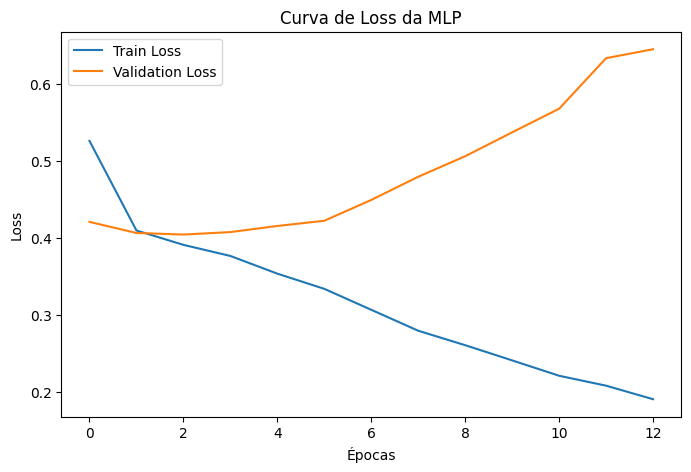

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Curva de Loss da MLP")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 📊 13. Avaliação no conjunto de teste

In [15]:
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_tensor.to(device)).cpu().numpy().ravel()

threshold = 0.3
y_pred = (y_pred_prob >= threshold).astype(int)

print(f"Threshold: {threshold}")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_prob))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

AUC: 0.84043504094655


## 📈 14. Métricas da MLP

In [16]:
mlp_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "auc_roc": roc_auc_score(y_test, y_pred_prob),
}

mlp_metrics


{'accuracy': 0.7629524485450674,
 'precision': 0.5375939849624061,
 'recall': 0.7647058823529411,
 'f1': 0.6313465783664459,
 'auc_roc': 0.84043504094655}

## 🧩 15. Matriz de confusão

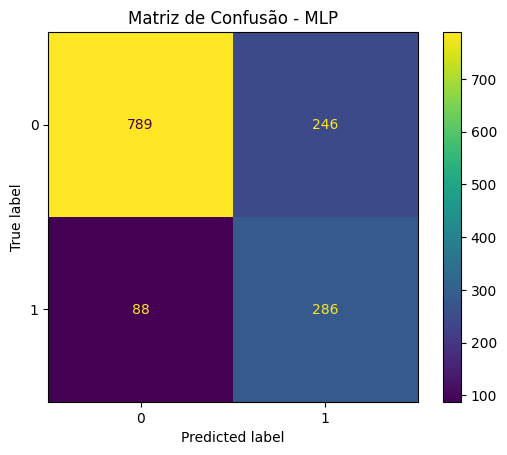

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusão - MLP")
plt.show()


## 📈 16. Curva ROC

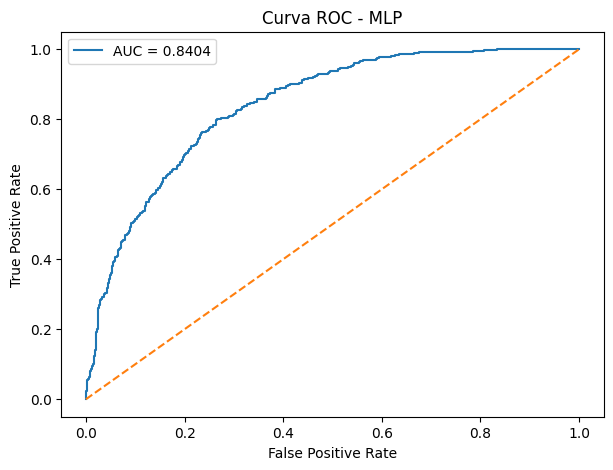

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - MLP")
plt.legend()
plt.show()


## 💸 17. Análise do trade-off de custo

In [19]:
cost_analysis = pd.DataFrame({
    "erro": ["Falso Positivo", "Falso Negativo"],
    "impacto_no_negocio": [
        "Cliente seria acionado indevidamente em uma campanha de retenção, gerando custo operacional e possível desconto desnecessário.",
        "Cliente em risco real não seria identificado, aumentando a chance de churn e perda de receita recorrente."
    ],
    "criticidade": ["Média", "Alta"]
})

cost_analysis


,erro,impacto_no_negocio,criticidade
0,Falso Positivo,Cliente seria acionado indevidamente em uma ca...,Média
1,Falso Negativo,"Cliente em risco real não seria identificado, ...",Alta


## 🧾 18. Tabela comparativa com os baselines

In [20]:
comparison_df = pd.DataFrame([
    {"model": "Logistic Regression (0.3)", "accuracy": 0.79, "precision": 0.54, "recall": 0.74, "f1": 0.623, "auc_roc": 0.84},
    {"model": "MLP (PyTorch)", "accuracy": round(mlp_metrics["accuracy"], 3), "precision": round(mlp_metrics["precision"], 3), "recall": round(mlp_metrics["recall"], 3), "f1": round(mlp_metrics["f1"], 3), "auc_roc": round(mlp_metrics["auc_roc"], 3)},
    {"model": "Random Forest", "accuracy": 0.80, "precision": 0.68, "recall": 0.48, "f1": 0.56, "auc_roc": 0.84},
    {"model": "Dummy Classifier", "accuracy": 0.73, "precision": 0.00, "recall": 0.00, "f1": 0.00, "auc_roc": np.nan},
])

comparison_df


,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression (0.3),0.790,0.540,0.740,0.623,0.84
1,MLP (PyTorch),0.763,0.538,0.765,0.631,0.84
2,Random Forest,0.800,0.680,0.480,0.560,0.84
3,Dummy Classifier,0.730,0.000,0.000,0.000,NaN


## 🧪 19. MLflow

In [21]:
MLFLOW_DIR = Path("../mlruns").resolve()
mlflow.set_tracking_uri(f"file:///{MLFLOW_DIR.as_posix()}")

mlflow.set_experiment("telco_churn_baselines")

with mlflow.start_run(run_name="mlp_v2_batching_early_stopping"):
    mlflow.log_param("model", "MLP")
    mlflow.log_param("input_dim", input_dim)
    mlflow.log_param("hidden_layer_1", 64)
    mlflow.log_param("hidden_layer_2", 32)
    mlflow.log_param("activation", "ReLU")
    mlflow.log_param("loss_function", "BCELoss")
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("epochs_max", EPOCHS)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("patience", PATIENCE)
    mlflow.log_param("threshold", threshold)

    mlflow.log_metric("best_val_loss", float(best_val_loss))
    for metric_name, metric_value in mlp_metrics.items():
        mlflow.log_metric(metric_name, float(metric_value))


## 📌 20. Conclusão

A MLP foi implementada com arquitetura explícita, função de ativação, loss function, batching e early stopping.
Os resultados devem ser comparados com os baselines lineares e de árvore.

Se a MLP não apresentar ganho significativo em relação à Regressão Logística, a decisão técnica pode favorecer a Logistic Regression por:
- simplicidade
- interpretabilidade
- menor custo de manutenção
- desempenho competitivo
